## Load dependencies

In [1]:
# --- standard ---
import os
import sys
import time
from datetime import datetime
from pathlib import Path

# --- scientific ---
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LightSource
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
import scipy.stats as stats

# --- machine learning / preprocessing ---
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- geostatistics ---
import skgstat as skg
from skgstat import models
import gstatsim as gs

# --- image / geometry utilities ---
from skimage.measure import find_contours

# --- parallelization ---
from joblib import Parallel, delayed

# --- local utilities (custom colormap) ---
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

# --- local multigrid SGSIM implementation ---
from mgsim import mgsim, mgsim_nst
import sampling
import trendmaking
from variograms import cluster_variogram, build_variogram_dataframe
from synthetic import extract_flightlines


## Load and plot data

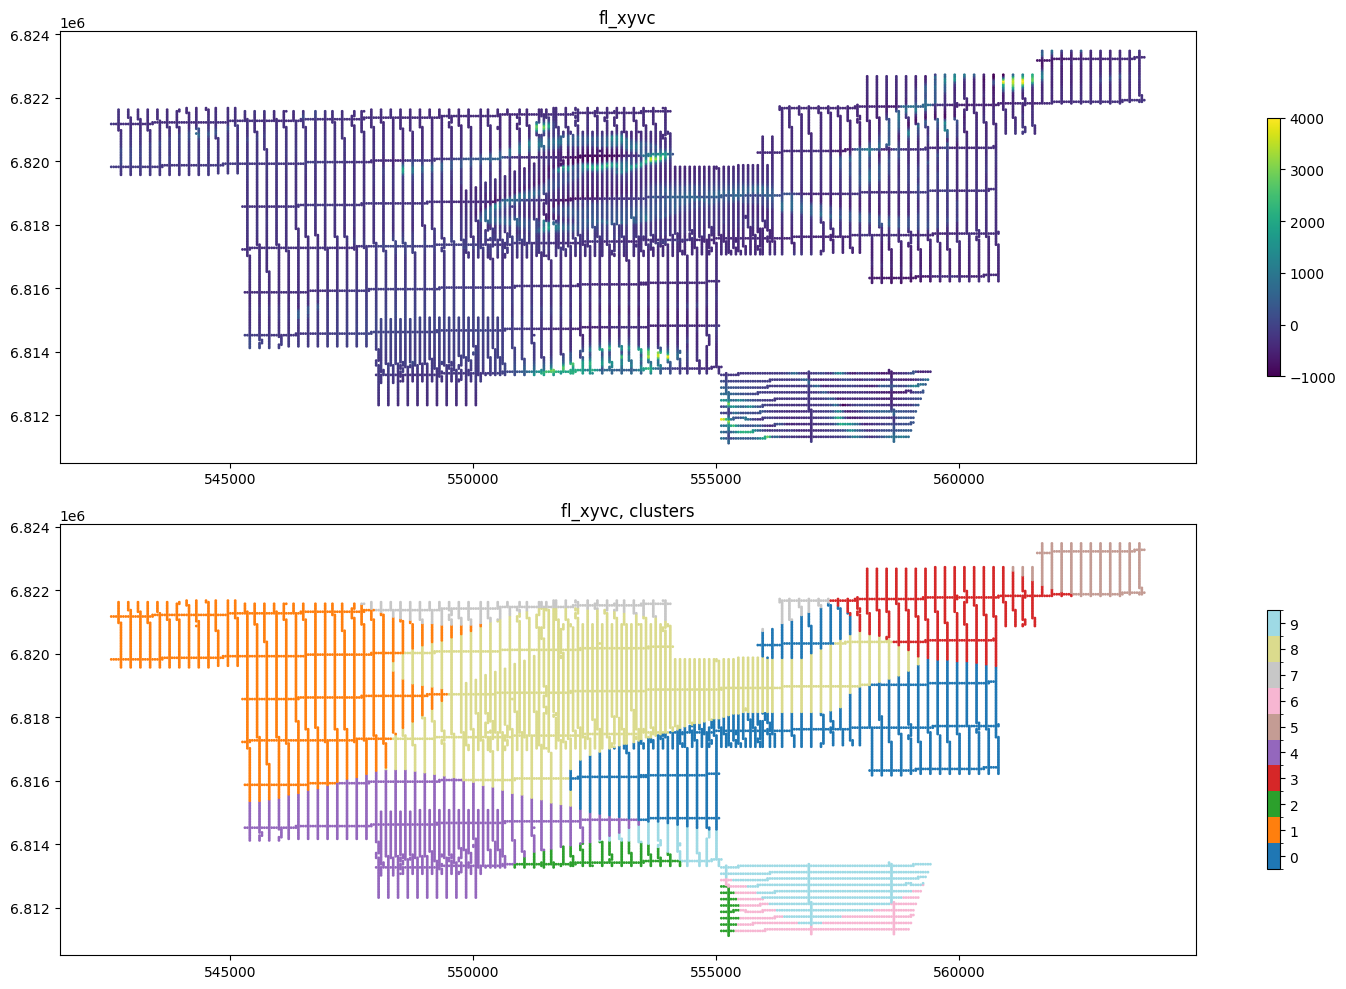

In [2]:
## LOAD AND PLOT CSB INFORMATION FROM .csv FILE ##
## ============================================ ##

# FLIGHT LINES
df_xyvmmc = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/data/csb_xyvmmc.csv')
df_fl_only = df_xyvmmc[df_xyvmmc["fl_mask"] == 1].drop(columns=["fl_mask", "grid_mask"], errors="ignore")
fl_xyvc = df_fl_only.values

# grid
df_grid_xyvc = df_xyvmmc.drop(columns=["fl_mask", "grid_mask"])

# get number of clusters from gt_xyvc
regions = fl_xyvc[:, 3]
unique_regions = np.unique(regions)
n_regions = len(unique_regions)
# set plot characteristics based on region clustering from gt_xyvc
cmap = plt.colormaps["tab20"].resampled(n_regions)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_regions+0.5, 1),
    ncolors=n_regions
)

# plot flight lines and clustering
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.scatter(fl_xyvc[:,0], fl_xyvc[:,1], c=fl_xyvc[:,2], s=1)
plt.title(f"fl_xyvc")
plt.colorbar(shrink=0.6)
plt.clim(-1000, 4000)

plt.subplot(2,1,2)
plt.title("fl_xyvc, values")
plt.scatter(fl_xyvc[:,0], fl_xyvc[:,1], c=fl_xyvc[:,3], cmap=cmap, norm=norm, s=1)
plt.title(f"fl_xyvc, clusters")
plt.colorbar(shrink=0.6, ticks=np.arange(n_regions))
plt.tight_layout()


## Withhold some flightlines

Holdout: 463 points at x=[551000, 553650, 555050]
Retained: 17100 points


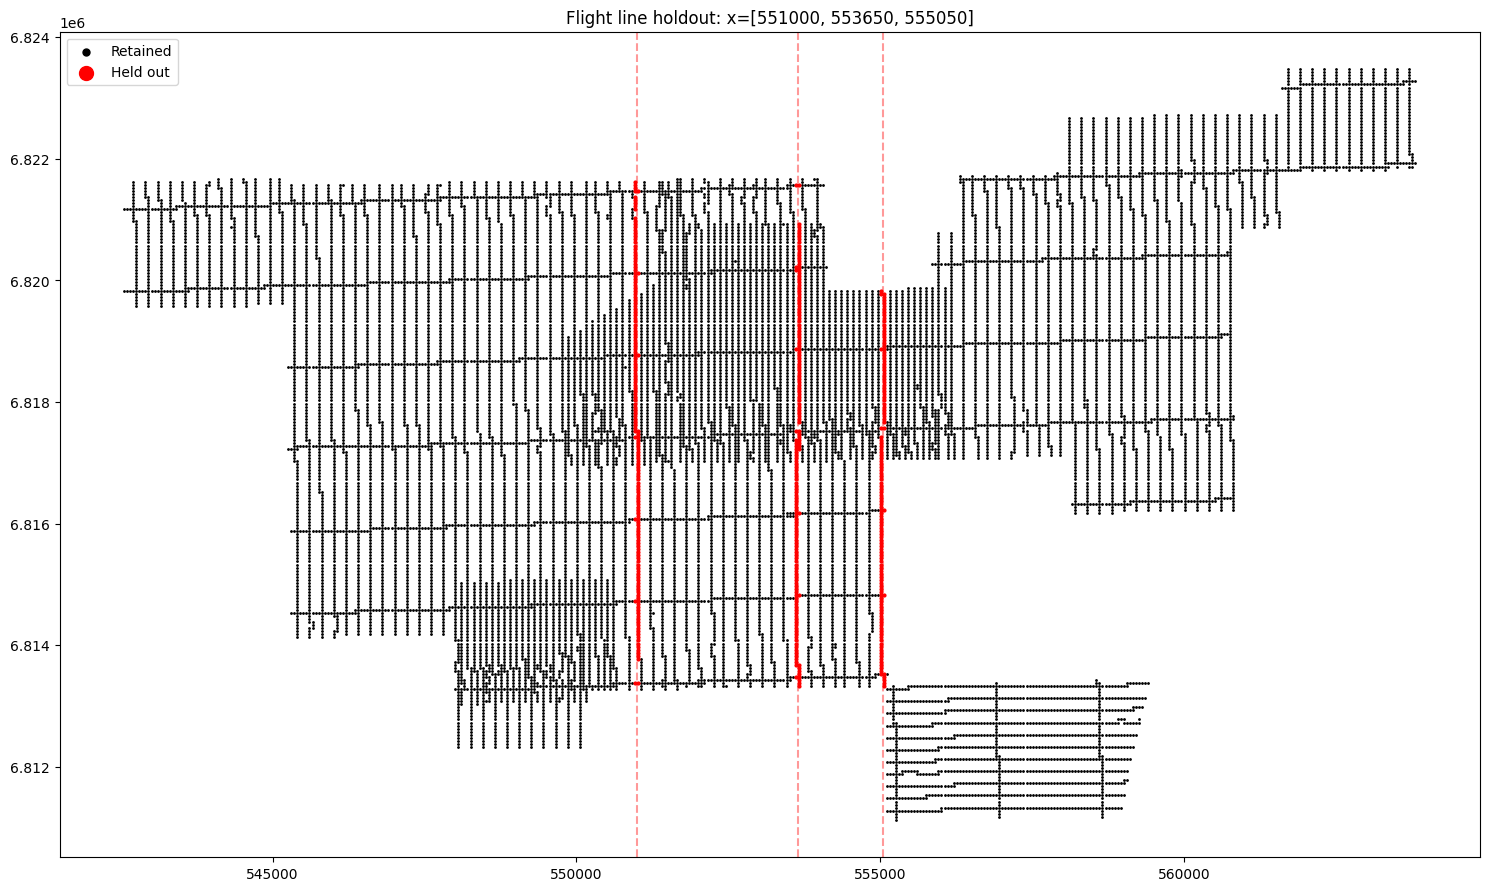

In [27]:
# Pick 3 N-S lines to hold out within x=[550000, 555000]
holdout_x_values = [551000, 553650, 555050]  # adjust as needed
tol = 50

holdout_mask = np.zeros(len(df_fl_only), dtype=bool)
for x_val in holdout_x_values:
    holdout_mask |= (df_fl_only['x'] - x_val).abs() <= tol

df_holdout = df_fl_only[holdout_mask].copy()
df_fl_reduced = df_fl_only[~holdout_mask].copy()

fl_xyvc = df_fl_reduced[['x', 'y', 'val', 'cluster']].values

print(f"Holdout: {len(df_holdout)} points at x={holdout_x_values}")
print(f"Retained: {len(df_fl_reduced)} points")

fig, ax = plt.subplots(figsize=(15, 10))

ax.scatter(df_fl_reduced['x'], df_fl_reduced['y'], s=1, c='black', label='Retained')
ax.scatter(df_holdout['x'], df_holdout['y'], s=4, c='red', label='Held out')

for x_val in holdout_x_values:
    ax.axvline(x_val, color='red', linestyle='--', alpha=0.4)

ax.set_aspect('equal')
ax.set_title(f"Flight line holdout: x={holdout_x_values}")
ax.legend(markerscale=5)
plt.tight_layout()


Holdout: 863 points at x=[548400, 551000, 553650, 555050, 558610, 560950]
Retained: 16700 points


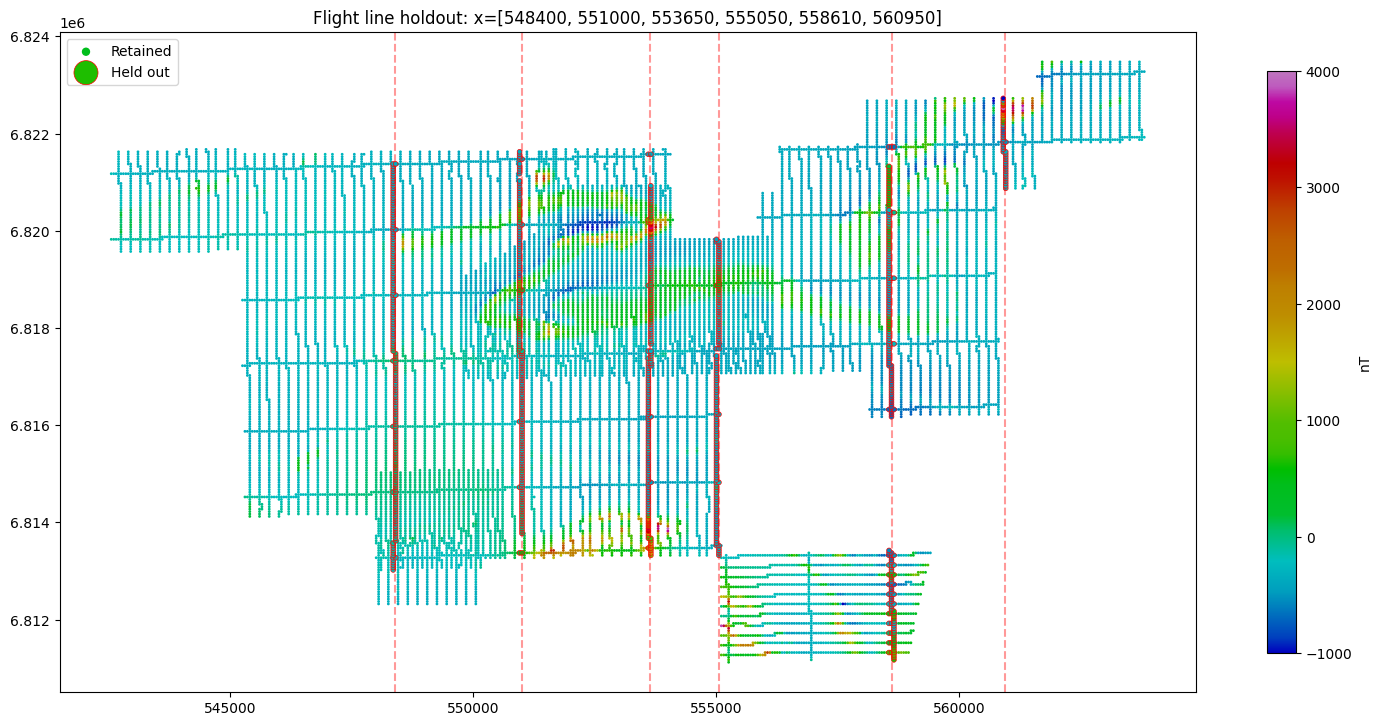

In [62]:
# Pick 3 N-S lines to hold out within x=[550000, 555000]
holdout_x_values = [548400, 551000, 553650, 555050, 558610, 560950]  # adjust as needed
tol = 55

holdout_mask = np.zeros(len(df_fl_only), dtype=bool)
for x_val in holdout_x_values:
    holdout_mask |= (df_fl_only['x'] - x_val).abs() <= tol

df_holdout = df_fl_only[holdout_mask].copy()
df_fl_reduced = df_fl_only[~holdout_mask].copy()

fl_xyvc = df_fl_reduced[['x', 'y', 'val', 'cluster']].values

print(f"Holdout: {len(df_holdout)} points at x={holdout_x_values}")
print(f"Retained: {len(df_fl_reduced)} points")

vmin, vmax = -1000, 4000

fig, ax = plt.subplots(figsize=(15, 10))

# Retained points colored by value
sc = ax.scatter(df_fl_reduced['x'], df_fl_reduced['y'], s=1,
                c=df_fl_reduced['val'], cmap=geosoft_cmap, vmin=vmin, vmax=vmax,
                label='Retained')

# Holdout points colored by value with red edge for visibility
ax.scatter(df_holdout['x'], df_holdout['y'], s=12,
           c=df_holdout['val'], cmap=geosoft_cmap, vmin=vmin, vmax=vmax,
           edgecolors='red', linewidths=0.5, label='Held out')

for x_val in holdout_x_values:
    ax.axvline(x_val, color='red', linestyle='--', alpha=0.4)

fig.colorbar(sc, ax=ax, shrink=0.6, label='nT')
ax.set_aspect('equal')
ax.set_title(f"Flight line holdout: x={holdout_x_values}")
ax.legend(markerscale=5)
plt.tight_layout()


In [6]:
df_fl_reduced

,x,y,val,cluster
254,555257.731488,6.811125e+06,439.156095,2
680,555257.731488,6.811175e+06,726.979416,2
714,556957.731488,6.811175e+06,-68.267416,6
748,558657.731488,6.811175e+06,654.151002,6
1106,555257.731488,6.811225e+06,569.160897,2
...,...,...,...,...
105629,562907.731488,6.823475e+06,-285.308969,5
105633,563107.731488,6.823475e+06,-432.937705,5
105637,563307.731488,6.823475e+06,-405.156363,5
105641,563507.731488,6.823475e+06,-347.260994,5


## Inspect results of ensemble

Found 50 files
Ensemble shape: (1000, 248, 426)  (realization, y, x)
Realizations: 0 to 999

E-type:  mean=-162.7, range=[-2999.1, 4112.2]


/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Std:     mean=4.8, range=[0.0, 159.5]


/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


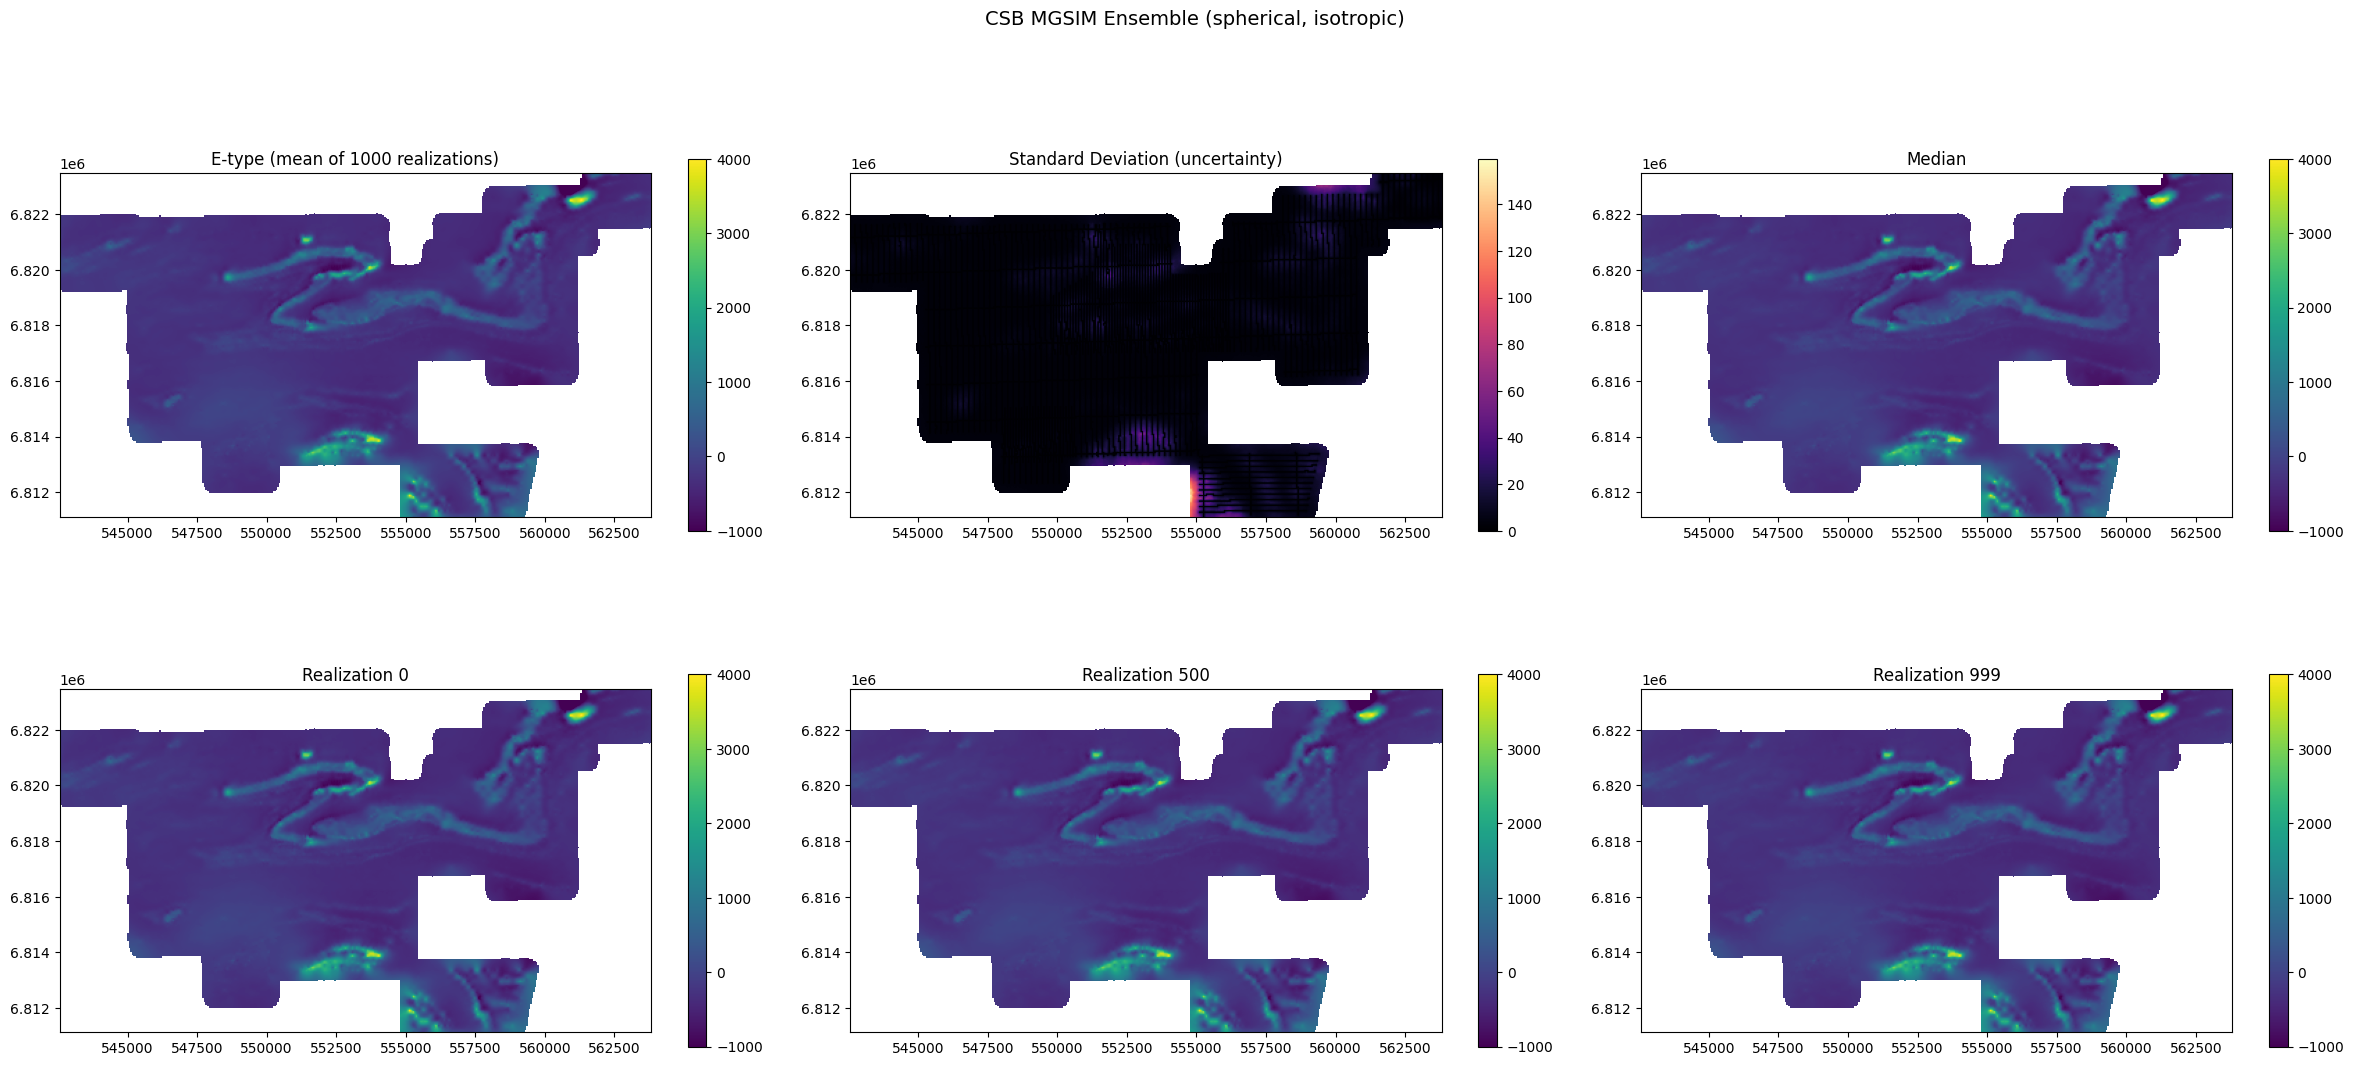

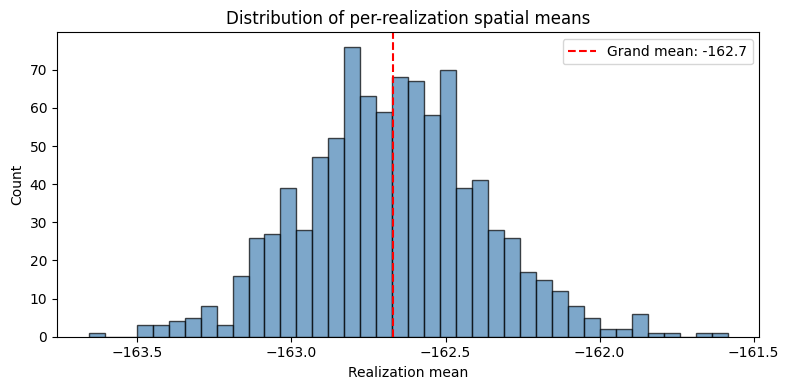

/Users/jrines/stanford_gp/research/mx/envMX/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [23]:
## LOAD AND INSPECT CSB MGSIM ENSEMBLE ##
## ==================================== ##

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable
from pathlib import Path
from glob import glob

# --- Load all realization chunks and concatenate ---
results_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock/csb/csb_sph_iso')
nc_files = sorted(results_dir.glob('realizations_*.nc'))
print(f"Found {len(nc_files)} files")

ds = xr.open_mfdataset(nc_files, combine='nested', concat_dim='realization')
ds = ds.sortby('realization')
print(f"Ensemble shape: {ds['simulated'].shape}  (realization, y, x)")
print(f"Realizations: {int(ds.realization.min())} to {int(ds.realization.max())}")

sim = ds['simulated']  # (1000, 248, 426)

# --- Compute summary statistics ---
e_type = sim.mean(dim='realization')       # E-type (mean) map
std_map = sim.std(dim='realization')        # Uncertainty map
median_map = sim.median(dim='realization')  # Median map

print(f"\nE-type:  mean={float(e_type.mean()):.1f}, range=[{float(e_type.min()):.1f}, {float(e_type.max()):.1f}]")
print(f"Std:     mean={float(std_map.mean()):.1f}, range=[{float(std_map.min()):.1f}, {float(std_map.max()):.1f}]")

# --- Plot: E-type, Std, and 3 individual realizations ---
vmin, vmax = -1000, 4000

fig, axes = plt.subplots(2, 3, figsize=(24, 12))

# Row 1: E-type, Std, Coefficient of Variation
im0 = axes[0, 0].imshow(e_type.values, origin='lower', 
                          extent=[float(ds.x.min()), float(ds.x.max()), 
                                  float(ds.y.min()), float(ds.y.max())],
                          vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title(f'E-type (mean of {len(ds.realization)} realizations)')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.6)

im1 = axes[0, 1].imshow(std_map.values, origin='lower',
                          extent=[float(ds.x.min()), float(ds.x.max()),
                                  float(ds.y.min()), float(ds.y.max())],
                          cmap='magma')
axes[0, 1].set_title('Standard Deviation (uncertainty)')
plt.colorbar(im1, ax=axes[0, 1], shrink=0.6)

im2 = axes[0, 2].imshow(median_map.values, origin='lower',
                          extent=[float(ds.x.min()), float(ds.x.max()),
                                  float(ds.y.min()), float(ds.y.max())],
                          vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 2].set_title('Median')
plt.colorbar(im2, ax=axes[0, 2], shrink=0.6)

# Row 2: 3 individual realizations
for i, real_idx in enumerate([0, 500, 999]):
    im = axes[1, i].imshow(sim.sel(realization=real_idx).values, origin='lower',
                             extent=[float(ds.x.min()), float(ds.x.max()),
                                     float(ds.y.min()), float(ds.y.max())],
                             vmin=vmin, vmax=vmax, cmap='viridis')
    axes[1, i].set_title(f'Realization {real_idx}')
    plt.colorbar(im, ax=axes[1, i], shrink=0.6)

plt.suptitle('CSB MGSIM Ensemble (spherical, isotropic)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Histogram of per-realization means ---
real_means = sim.mean(dim=['y', 'x']).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_means, bins=40, color='steelblue', edgecolor='k', alpha=0.7)
ax.axvline(np.nanmean(real_means), color='red', linestyle='--', label=f'Grand mean: {np.nanmean(real_means):.1f}')
ax.set_xlabel('Realization mean')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-realization spatial means')
ax.legend()
plt.tight_layout()
plt.show()


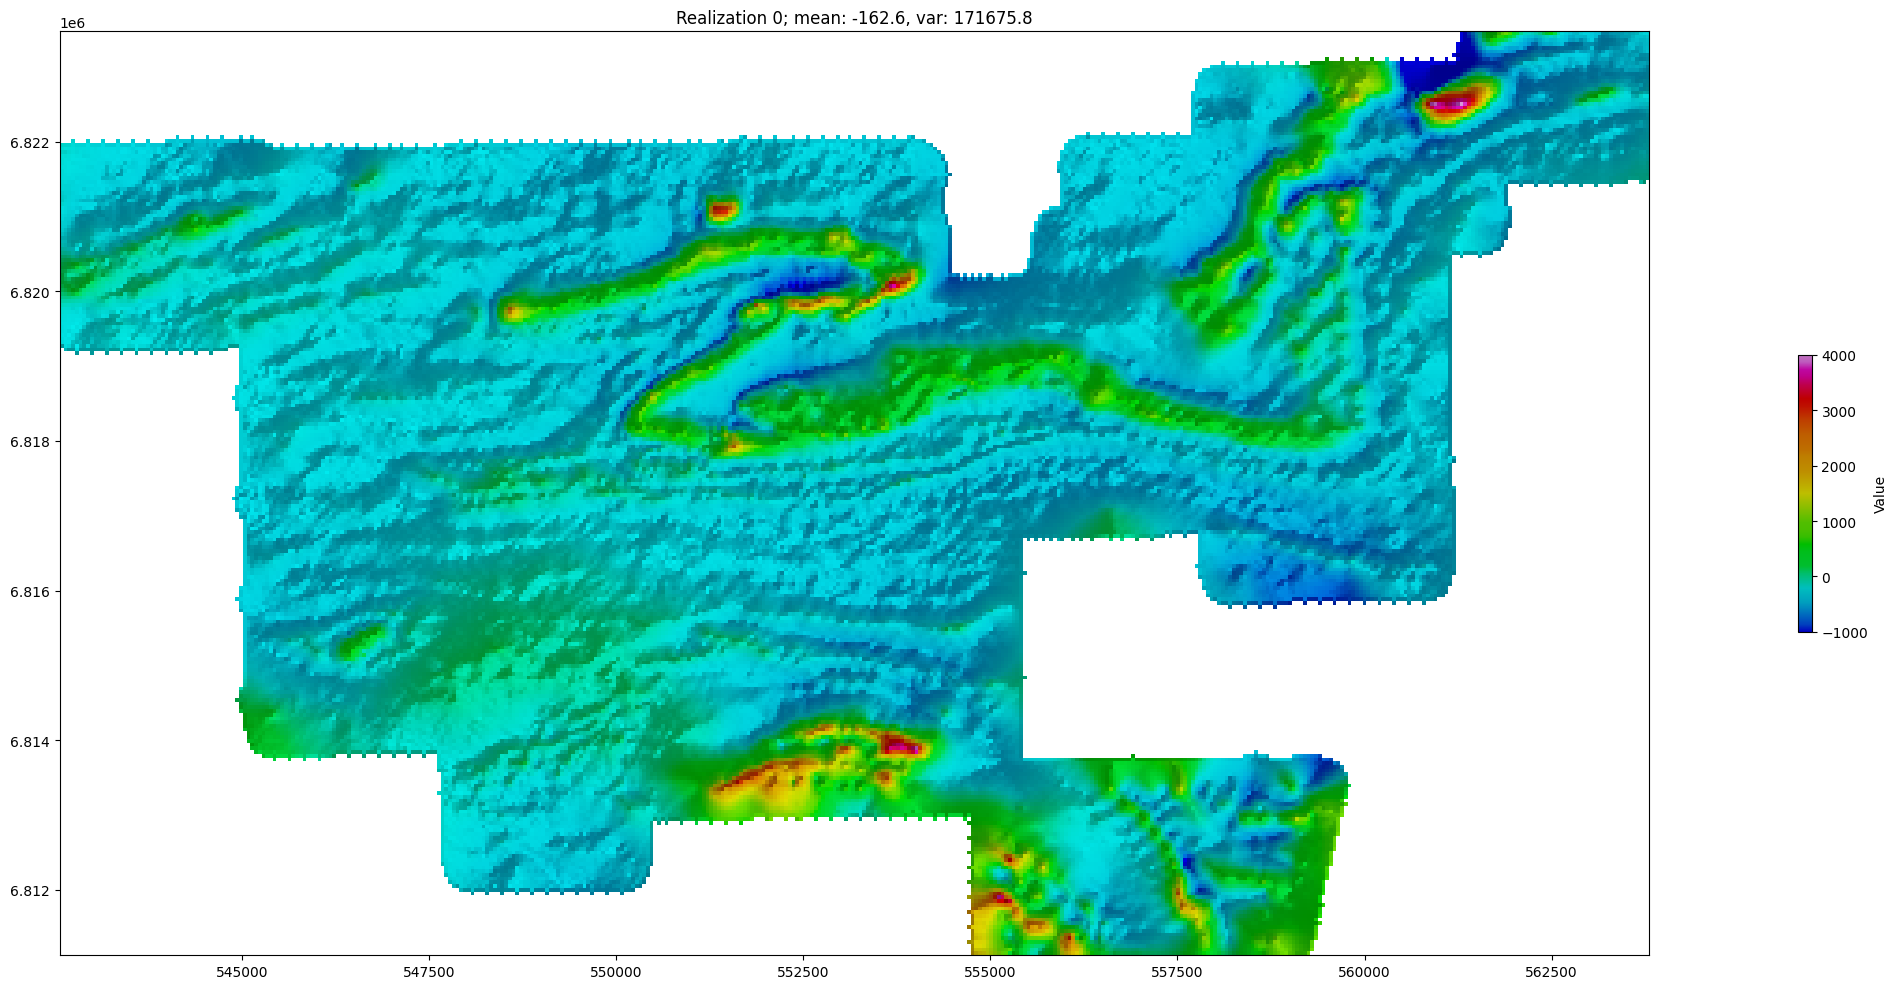

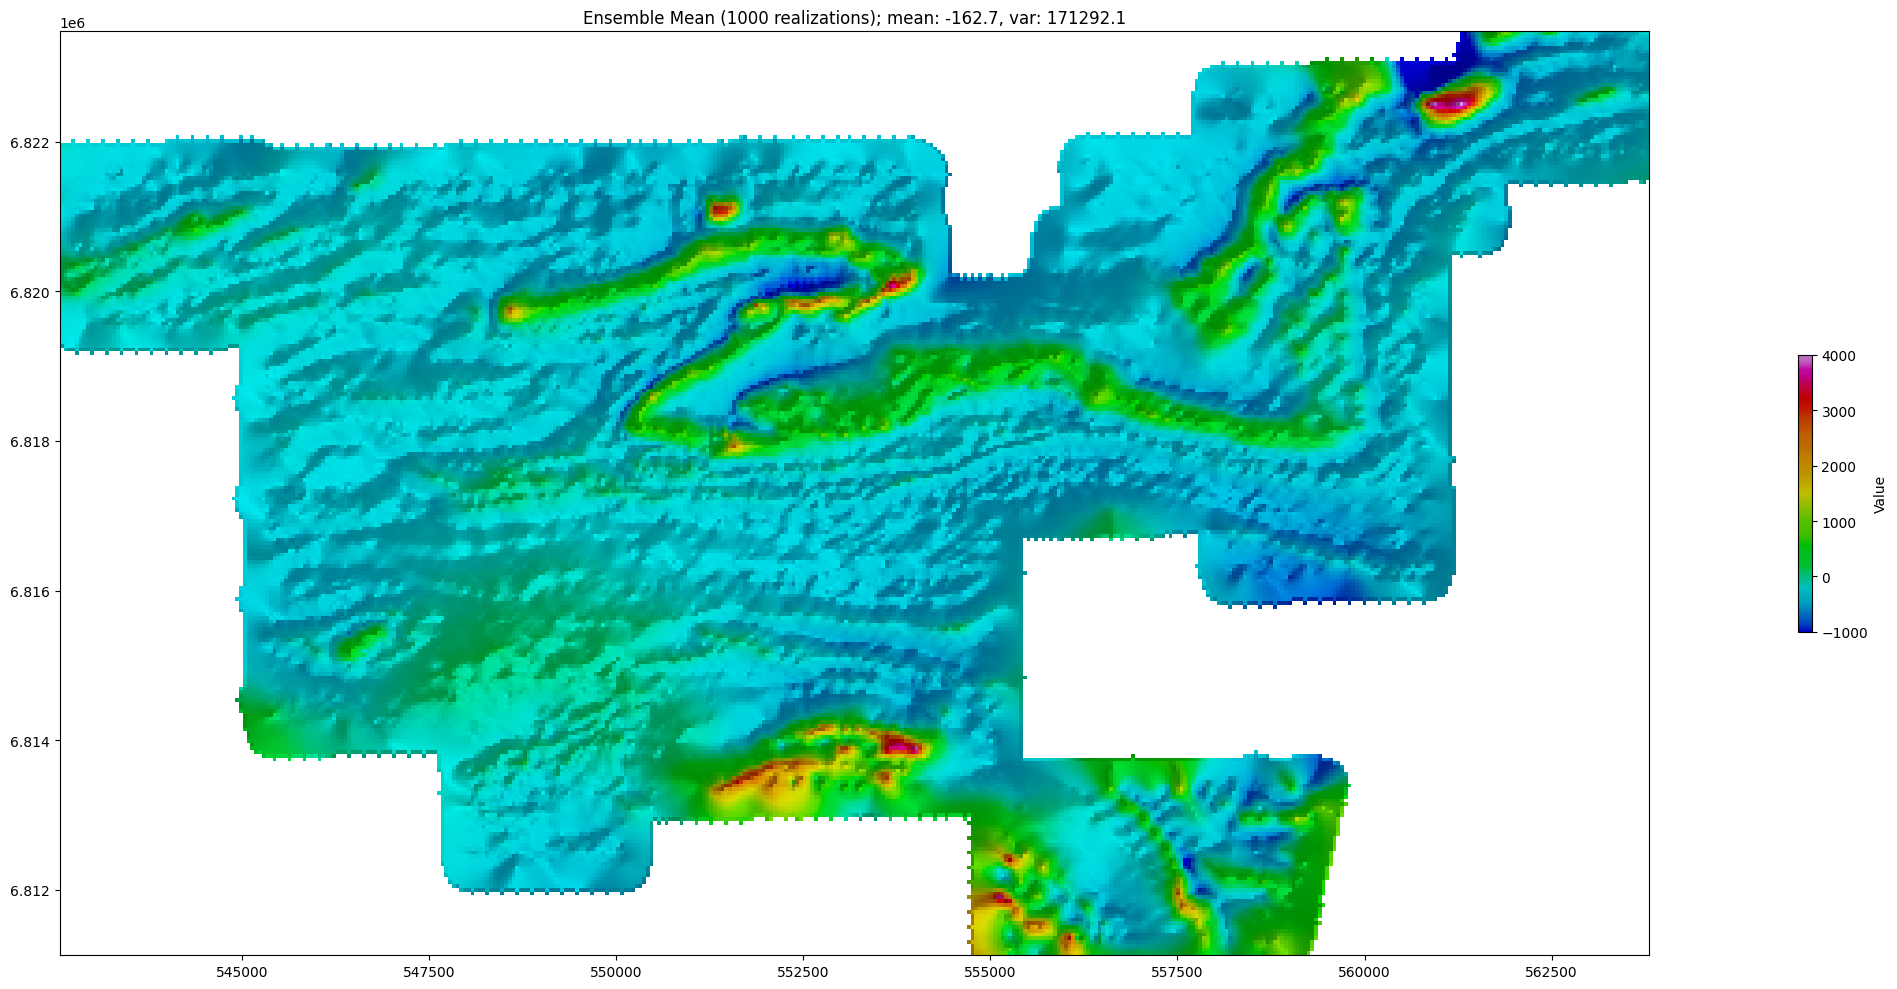

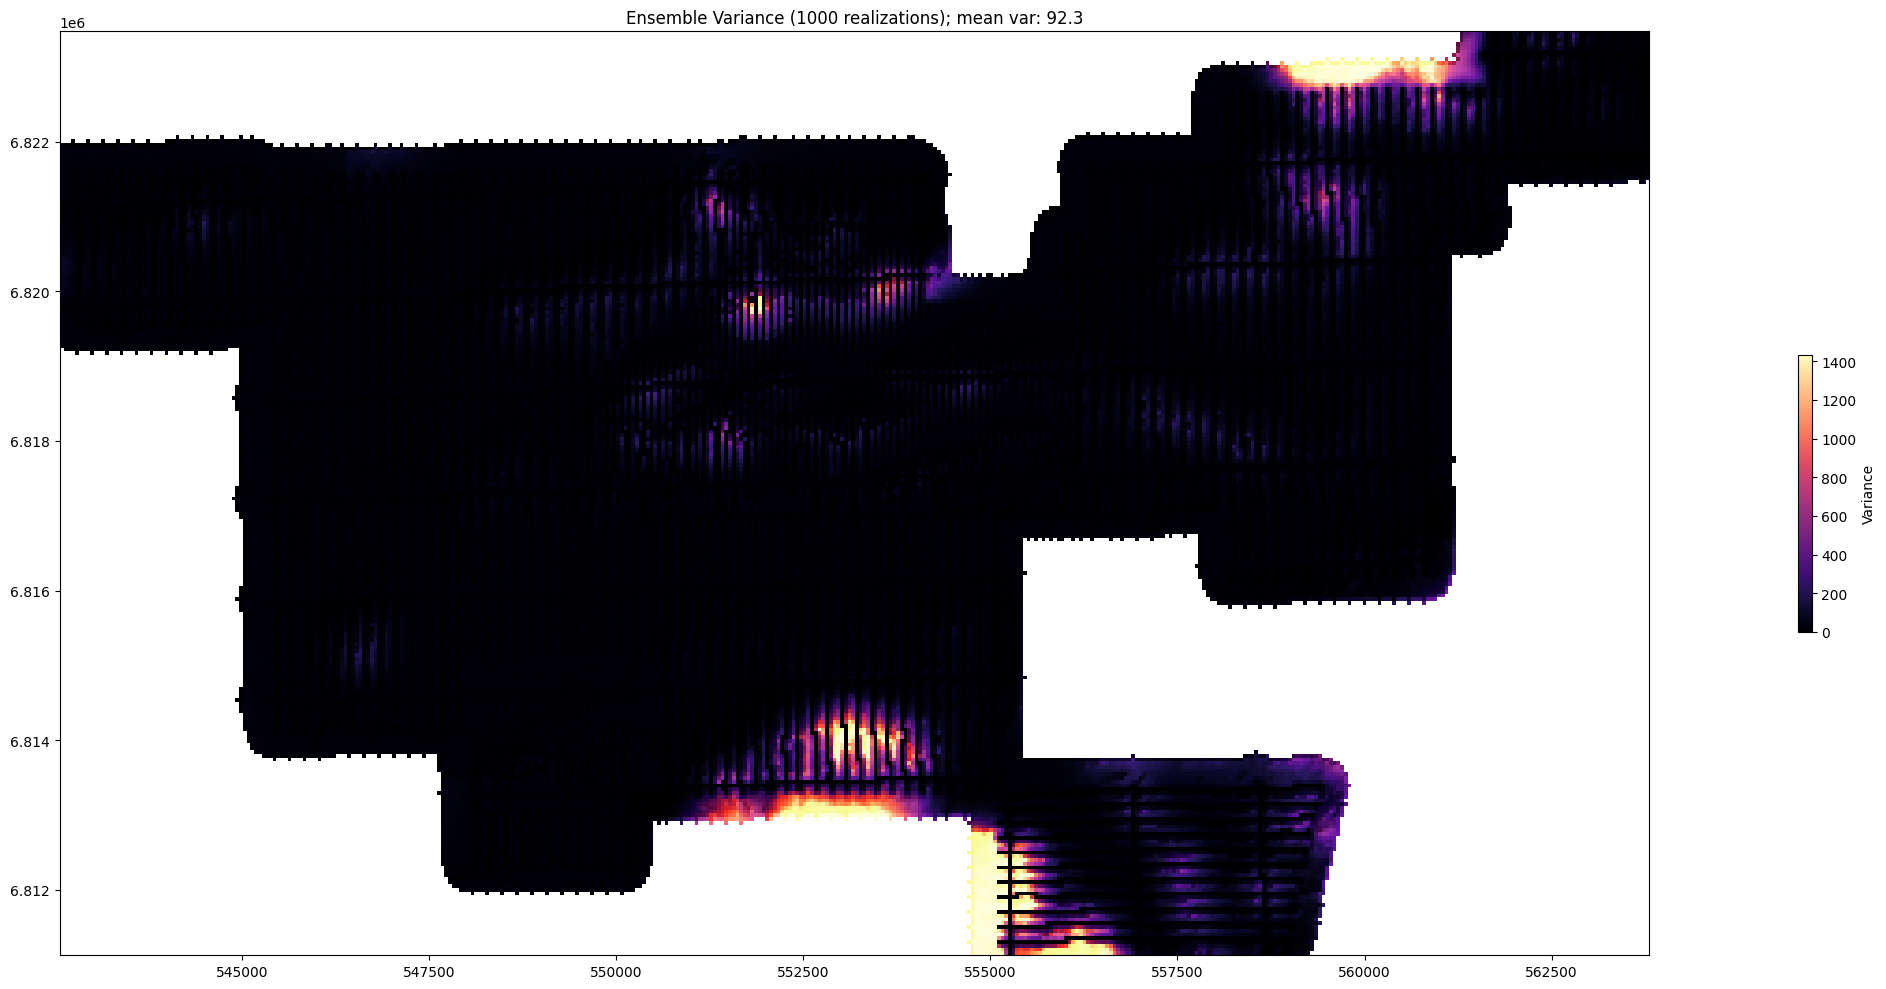

In [24]:
## ENSEMBLE SUMMARY PLOTS (hillshade) ##
## =================================== ##

ls = LightSource(azdeg=45, altdeg=45)
extent = [float(ds.x.min()), float(ds.x.max()), float(ds.y.min()), float(ds.y.max())]
vmin, vmax = -1000, 4000
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=geosoft_cmap)
mappable.set_array([])

def shade_and_mask(mat, cmap, vmin, vmax):
    """Hillshade with NaN regions whited out."""
    nan_mask = np.isnan(mat)
    filled = np.where(nan_mask, 0, mat)
    rgb = ls.shade(filled, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
    rgb[nan_mask] = [1, 1, 1, 1]
    return rgb

# --- 1. One example realization ---
real_idx = 0
mat = sim.sel(realization=real_idx).values

fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(shade_and_mask(mat, geosoft_cmap, vmin, vmax), origin='lower', extent=extent)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_title(f"Realization {real_idx}; mean: {np.nanmean(mat):.1f}, var: {np.nanvar(mat):.1f}")
fig.colorbar(mappable, ax=ax, shrink=0.3, label="Value")
plt.tight_layout()
plt.show()

# --- 2. Ensemble mean ---
mat_mean = e_type.values

fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(shade_and_mask(mat_mean, geosoft_cmap, vmin, vmax), origin='lower', extent=extent)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_title(f"Ensemble Mean ({len(ds.realization)} realizations); mean: {np.nanmean(mat_mean):.1f}, var: {np.nanvar(mat_mean):.1f}")
fig.colorbar(mappable, ax=ax, shrink=0.3, label="Value")
plt.tight_layout()
plt.show()

# --- 3. Ensemble variance (hillshade with magma) ---
mat_var = sim.var(dim='realization').values
mat_var = np.where(np.isnan(e_type.values), np.nan, mat_var)
var_vmin, var_vmax = 0, np.nanpercentile(mat_var, 99)
mappable_var = ScalarMappable(norm=Normalize(vmin=var_vmin, vmax=var_vmax), cmap='magma')
mappable_var.set_array([])

fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(shade_and_mask(mat_var, plt.cm.magma, var_vmin, var_vmax), origin='lower', extent=extent)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_title(f"Ensemble Variance ({len(ds.realization)} realizations); mean var: {np.nanmean(mat_var):.1f}")
fig.colorbar(mappable_var, ax=ax, shrink=0.3, label="Variance")
plt.tight_layout()
plt.show()
